# MaxEnt Test Cases

Loads a test case from `examples/maxent_tests/`, runs the SMM solver,
and checks the recovered distribution against analytically expected properties.

| Case | File | Type |
|------|------|------|
| `single_mean` | `case_single_mean.py` | **Mathematically obvious** — mean constraint shifts a single distribution |
| `independent_marginals` | `case_independent_marginals.py` | **Mathematically obvious** — no joint info → MaxEnt enforces independence |
| `chain_propagation` | `case_chain_propagation.py` | Analytic marginals via law of total probability |
| `conditional_expectation` | `case_conditional_expectation.py` | Analytic mean via law of total expectation |
| `bayes_net_fork` | `case_bayes_net_fork.py` | Fork Bayes net A→B, A→C — two CPT rows per child; tests common-cause correlation and conditional independence |

In [44]:
%load_ext autoreload
%autoreload 2

import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp

from calibrated_response.energy_models.feature_weight import FeatureWeightModel
from calibrated_response.maxent_smm.distribution_builder import DistributionBuilder
from calibrated_response.maxent_smm.maxent_solver import JAXSolverConfig
from calibrated_response.models.variable import VariableType

print('JAX devices:', jax.devices())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX devices: [CpuDevice(id=0)]


## Select a test case

Change `CASE_NAME` to one of:
- `"single_mean"`
- `"independent_marginals"`
- `"chain_propagation"`
- `"conditional_expectation"`
- `"bayes_net_fork"`

In [45]:
CASE_NAME = "single_mean"   # ← change this

_module_map = {
    "single_mean":             "examples.maxent_tests.case_single_mean",
    "independent_marginals":   "examples.maxent_tests.case_independent_marginals",
    "chain_propagation":       "examples.maxent_tests.case_chain_propagation",
    "conditional_expectation": "examples.maxent_tests.case_conditional_expectation",
    "bayes_net_fork":          "examples.maxent_tests.case_bayes_net_fork",
}

if CASE_NAME not in _module_map:
    raise ValueError(f"Unknown case '{CASE_NAME}'. Choose from: {list(_module_map)}")

case = importlib.import_module(_module_map[CASE_NAME])

print(f"Case:        {case.NAME}")
print(f"Description: {case.DESCRIPTION}")
print()
print(f"Math:        {case.MATH_DESCRIPTION}")
print()
print(f"Variables ({len(case.variables)}): {[v.name for v in case.variables]}")
print(f"Estimates ({len(case.estimates)}):")
for est in case.estimates:
    print(f"  • {est.to_query_estimate()}")

Case:        single_mean
Description: Single variable X on [0, 100] with only E[X] = 25 specified.
MaxEnt tilts toward the lower end; the recovered mean must equal 25.

Math:        The maximum-entropy distribution on [0, 100] with E[X] = 25 is a
truncated exponential p(x) ∝ exp(λx) with λ < 0.  The solver must
place the mean at exactly 25.  No correlation is expected (one variable).

Variables (1): ['X']
Estimates (1):
  • E[X] = 25.0


## Solver configuration

Adjust `num_iterations` / `num_chains` for speed vs. accuracy.

In [46]:
config = JAXSolverConfig(
    num_chains=256,
    num_iterations=2500,
    mcmc_steps_per_iteration=10,
    learning_rate=1e-4,
    l2_regularization=1e-3,
    hmc_step_size=0.015,
    hmc_leapfrog_steps=3,
    seed=42,
    verbose=True,
    continuous_prior="gaussian",
    energy_reg_weight=1e-2,
)

builder = DistributionBuilder(
    variables=case.variables,
    estimates=case.estimates,
    solver_config=config,
)

# # Use the feature-weight (classical MaxEnt) energy model
# feature_model = FeatureWeightModel(feature_specs=builder.feature_specs)
# params_pytree = feature_model.init_params(jax.random.PRNGKey(0))
# params = feature_model.pack_params(params_pytree)
# energy_fn = feature_model.energy_fn_flat

from calibrated_response.energy_models.neural import NeuralEnergyModel
nn_model = NeuralEnergyModel(len(case.variables), hidden_sizes=[256, 256], n_freqs=8)
params_pytree = nn_model.init_params(jax.random.PRNGKey(0))
params = nn_model.pack_params(params_pytree)
energy_fn = nn_model.energy_fn_flat

print(f"Feature-weight model: {len(builder.feature_specs)} features")
if builder.skipped:
    print(f"Skipped estimates: {builder.skipped}")

Feature-weight model: 1 features


In [47]:
solver, info = builder.run_solver(energy_fn=energy_fn, init_theta=params)

print(f"\nConverged:  {info['converged']}")
print(f"Features:   {info['n_features']}")
print(f"Skipped:    {info['skipped_constraints']}")

Compiled maxent solver
[MaxEntSolver] iter   50  max_err=0.225066  mean_err=0.225066  mean_squared_err=0.050655  accept=0.904  step_size=0.17201
[MaxEntSolver] iter  100  max_err=0.182774  mean_err=0.182774  mean_squared_err=0.033406  accept=0.619  step_size=0.24112
[MaxEntSolver] iter  150  max_err=0.098342  mean_err=0.098342  mean_squared_err=0.009671  accept=0.627  step_size=0.16775
[MaxEntSolver] iter  200  max_err=0.072326  mean_err=0.072326  mean_squared_err=0.005231  accept=0.635  step_size=0.14257
[MaxEntSolver] iter  250  max_err=0.082912  mean_err=0.082912  mean_squared_err=0.006874  accept=0.613  step_size=0.16360
[MaxEntSolver] iter  300  max_err=0.081992  mean_err=0.081992  mean_squared_err=0.006723  accept=0.644  step_size=0.16985
[MaxEntSolver] iter  350  max_err=0.031154  mean_err=0.031154  mean_squared_err=0.000971  accept=0.638  step_size=0.17634
[MaxEntSolver] iter  400  max_err=0.067903  mean_err=0.067903  mean_squared_err=0.004611  accept=0.639  step_size=0.18308
[

In [48]:
solver = builder.solver
batch_feature_fn = solver._batch_feature_fn
chain_samples = builder.solver._buffer.states
feature_val = batch_feature_fn(chain_samples)
feature_expectations = jnp.mean(feature_val, axis=0)
for spec, target, expectation in zip(builder.feature_specs, builder.feature_targets, feature_expectations):
    print(spec)
    print(f"  Target: {target:.4f}")
    print(f"  Expectation: {expectation:.4f}")

MomentFeature(var_idx=0, order=1)
  Target: 0.2500
  Expectation: 0.3141


In [49]:
samples = info["energy_model"].sample(n_samples=5000)

In [50]:
feature_val = batch_feature_fn(samples)
feature_expectations = jnp.mean(feature_val, axis=0)
for spec, target, expectation in zip(builder.feature_specs, builder.feature_targets, feature_expectations):
    print(spec)
    print(f"  Target: {target:.4f}")
    print(f"  Expectation: {expectation:.4f}")

MomentFeature(var_idx=0, order=1)
  Target: 0.2500
  Expectation: 0.3054


## Convergence plots

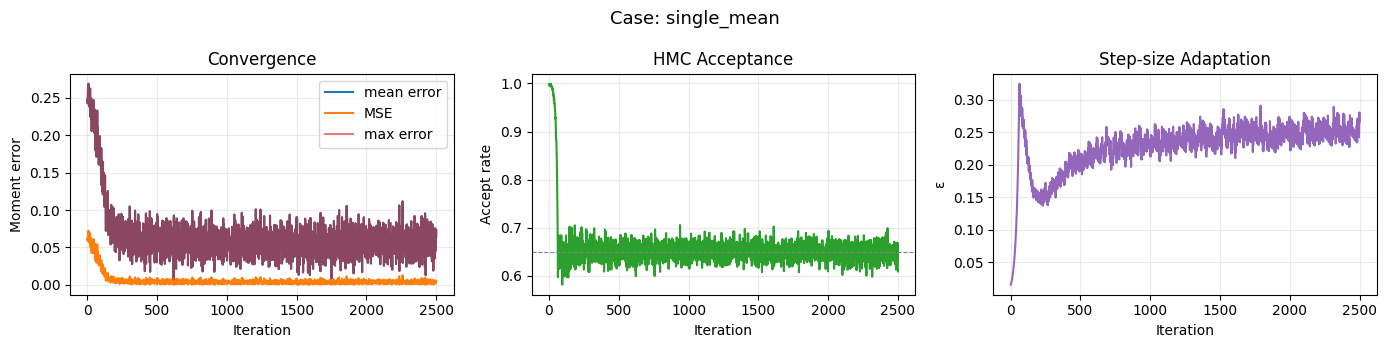

Final max error:   0.06411
Final mean error:  0.06411
Final accept rate: 0.609


In [51]:
history = info["history"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(history["iteration"], history["mean_error"],         label="mean error",    color="C0")
axes[0].plot(history["iteration"], history["mean_squared_error"], label="MSE",           color="C1")
axes[0].plot(history["iteration"], history["max_error"],          label="max error",     color="C3", alpha=0.6)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Moment error")
axes[0].set_title("Convergence"); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(history["iteration"], history["accept_rate"], color="C2")
axes[1].axhline(config.target_accept_rate, ls="--", color="gray", lw=0.8)
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Accept rate")
axes[1].set_title("HMC Acceptance"); axes[1].grid(alpha=0.25)

axes[2].plot(history["iteration"], history["step_size"], color="C4")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("ε")
axes[2].set_title("Step-size Adaptation"); axes[2].grid(alpha=0.25)

plt.suptitle(f"Case: {case.NAME}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Final max error:   {history['max_error'][-1]:.5f}")
print(f"Final mean error:  {history['mean_error'][-1]:.5f}")
print(f"Final accept rate: {history['accept_rate'][-1]:.3f}")

## Draw samples

In [52]:
energy_model = info["energy_model"]

# sample_original() returns values in original variable domains.
# Binary variables remain in [0, 1] (> 0.5 means True).
samples_original = energy_model.sample_original(n_samples=3000)
variable_names = [v.name for v in case.variables]

print(f"Samples shape: {samples_original.shape}")
for i, var in enumerate(case.variables):
    col = samples_original[:, i]
    print(f"  {var.name}: mean={np.mean(col):.3f}  std={np.std(col):.3f}  "
          f"min={np.min(col):.3f}  max={np.max(col):.3f}")

Samples shape: (3000, 1)
  X: mean=30.135  std=24.132  min=0.034  max=99.905


## Marginal distributions

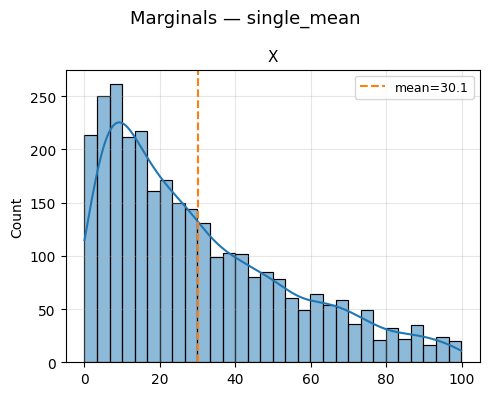

In [53]:
n_vars = len(case.variables)
n_cols = min(3, n_vars)
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for idx, var in enumerate(case.variables):
    ax = axes_flat[idx]
    col = samples_original[:, idx]

    if var.type == VariableType.BINARY:
        # Plot as bar chart: False (≤0.5) vs True (>0.5)
        counts = [np.sum(col <= 0.5), np.sum(col > 0.5)]
        ax.bar(["False", "True"], [c / len(col) for c in counts], color=["C3", "C0"], alpha=0.75)
        ax.set_ylabel("Probability")
    else:
        sns.histplot(col, bins=30, kde=True, ax=ax, color="C0")
        ax.axvline(np.mean(col), color="C1", lw=1.5, ls="--", label=f"mean={np.mean(col):.1f}")
        ax.legend(fontsize=9)

    ax.set_title(f"{var.name}", fontsize=11)
    ax.grid(True, alpha=0.3)

for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle(f"Marginals — {case.NAME}", fontsize=13)
plt.tight_layout()
plt.show()

## Pairplot (joint distributions)

Only shown for cases with two or more variables.

In [54]:
import pandas as pd

if len(case.variables) >= 2:
    df = pd.DataFrame(samples_original, columns=variable_names)
    g = sns.pairplot(df, plot_kws=dict(alpha=0.2, s=4), diag_kws=dict(bins=25))
    g.figure.suptitle(f"Pairplot — {case.NAME}", y=1.02, fontsize=13)
    plt.show()

    print("Pearson correlations:")
    print(df.corr().round(3))
else:
    print("Only one variable — pairplot not shown.")

Only one variable — pairplot not shown.


## Checks against expected values

In [55]:
checks = case.check_results(samples_original, variable_names)

n_pass = sum(c["passed"] for c in checks)
n_total = len(checks)

print(f"Results for: {case.NAME}")
print(f"{'Check':<38} {'Value':>10} {'Expected':>12} {'Tol':>8} {'Status':>8}")
print("-" * 80)
for c in checks:
    status = "PASS ✓" if c["passed"] else "FAIL ✗"
    tol_str = f"±{c['tolerance']}" if c["tolerance"] is not None else "n/a"
    val_str = str(c["value"]) if c["value"] is not None else "N/A"
    print(f"{c['name']:<38} {val_str:>10} {str(c['expected']):>12} {tol_str:>8} {status:>8}")
    if c.get("note"):
        print(f"  ↳ {c['note']}")

print("-" * 80)
print(f"Summary: {n_pass}/{n_total} checks passed")

Results for: single_mean
Check                                       Value     Expected      Tol   Status
--------------------------------------------------------------------------------
E[X]                                        30.14         25.0     ±4.0   FAIL ✗
  ↳ Mean must match the single specified constraint.
X is biased low (mean < 50)                 30.14         < 50      n/a   PASS ✓
  ↳ Mean constraint below midpoint must shift distribution downward.
--------------------------------------------------------------------------------
Summary: 1/2 checks passed


---
## Run all cases (batch mode)

Runs every test case sequentially and prints a summary table.  
**This cell is slow** — each case runs the full SMM solver.

In [ ]:
ALL_CASES = [
    "examples.maxent_tests.case_single_mean",
    "examples.maxent_tests.case_independent_marginals",
    "examples.maxent_tests.case_chain_propagation",
    "examples.maxent_tests.case_conditional_expectation",
    "examples.maxent_tests.case_bayes_net_fork",
]

batch_config = JAXSolverConfig(
    num_chains=512,
    num_iterations=600,
    mcmc_steps_per_iteration=6,
    learning_rate=0.0001,
    l2_regularization=1e-5,
    hmc_step_size=0.015,
    hmc_leapfrog_steps=10,
    max_bins=15,
    seed=42,
    verbose=False,
    continuous_prior="gaussian",
)

all_results = {}  # case_name → list of check dicts

for mod_path in ALL_CASES:
    tc = importlib.import_module(mod_path)
    print(f"\n{'='*60}")
    print(f"Running: {tc.NAME}")
    print(f"  {tc.DESCRIPTION}")

    b = DistributionBuilder(
        variables=tc.variables,
        estimates=tc.estimates,
        solver_config=batch_config,
    )
    fm = FeatureWeightModel(feature_specs=b.feature_specs)
    p0 = fm.pack_params(fm.init_params(jax.random.PRNGKey(0)))

    _, inf = b.run_solver(energy_fn=fm.energy_fn_flat, init_theta=p0)
    em = inf["energy_model"]
    samps = em.sample_original(n_samples=3000)
    vnames = [v.name for v in tc.variables]

    checks = tc.check_results(samps, vnames)
    all_results[tc.NAME] = checks

    n_pass = sum(c["passed"] for c in checks)
    print(f"  → {n_pass}/{len(checks)} checks passed  "
          f"(final mean error={inf['history']['mean_error'][-1]:.4f})")

# ── Summary table ────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("BATCH SUMMARY")
print(f"{'Case':<30} {'Passed':>8} {'Total':>8}")
print("-" * 50)
for name, checks in all_results.items():
    n_pass = sum(c["passed"] for c in checks)
    status = "✓" if n_pass == len(checks) else "✗"
    print(f"{name:<30} {n_pass:>8} {len(checks):>8}  {status}")